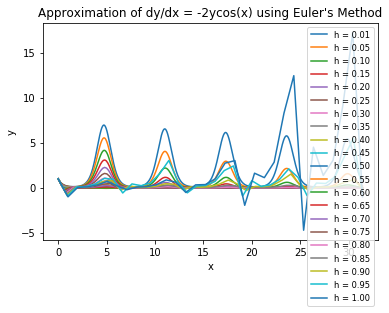

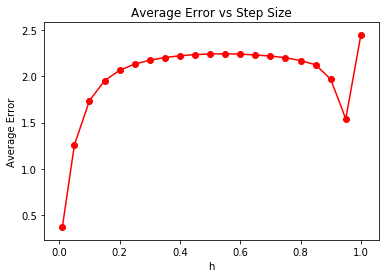

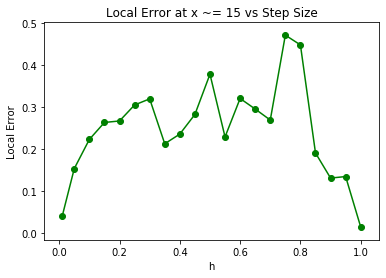

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 10*np.pi

def Parameters(h):
    
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1  # y(0) = 1
    return num_steps, x_values, y_values

# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Analytical solution
def analytical_f(x):
    return np.exp(-2 * np.sin(x))

h_values = np.arange(0,1.05,.05)
h_values[0] = .01
avg_error = np.zeros(len(h_values))
local_error = np.zeros(len(h_values))

for index, h in enumerate(h_values):
    
    num_steps, x_values, y_values = Parameters(h)
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    # Average Error
    y_analytical = analytical_f(x_values)
    avg_error[index] = np.mean(np.abs((y_analytical - y_values)))
    
    # Local error for x ~= 15
    idx = np.argmin(np.abs(x_values - 15))
    x_local = x_values[idx]
    local_error[index] = np.abs(analytical_f(x_local) - y_values[idx])
    
    plt.plot(x_values, y_values, label=f'h = {h:.2f}')
    
# Plotting Euler's Method
plt.xlabel('x')
plt.ylabel('y')
plt.title(f"Approximation of dy/dx = -2ycos(x) using Euler's Method")
plt.legend(fontsize = 'small')
plt.show()

# Plotting average error
plt.plot(h_values, avg_error, 'r-')
plt.scatter(h_values, avg_error, color = 'red')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.show()

# Plotting local error
plt.plot(h_values, local_error, 'g-')
plt.scatter(h_values, local_error, color = 'green')
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title('Local Error at x ~= 15 vs Step Size')
plt.show() 

In the first graph, as step sizes h increase, the solutions have amplitude distortion because error for Euler's Method is proportional to the step size. 

In the second graph, the everage errors generally increase over time. However, there are some points where the solutions oscillate so much that the average error is closer to the analytical solution by coincidence. 

In the third graph, local error appears to change randomly because solutions with different step sizes can sometimes shift relative to each other, causing variation.

#### Stability Analysis Addendum:

To perform stability analysis, we can plug f(x,y) = -2ycos(x) into yn+1 = yn + hf(x,y) to get:
    yn+1 = yn(1-2hcos(x)).
As a result, 1-2hcos(x) is lambda, the amplification factor. For Euler's Method to be stable, the absolute value of lambda has to be less than or equal to 1, so the absolute value of 1-2hcos(x) being less than or equal to 1 is the stability condition for f(x,y) = -2ycos(x). Since lamba depends on x, stability varies with each step, so Euler's Method could be stable for some parts and unstable for others, no matter what h is chosen.